
# 🌟 **Bank Marketing Classification using Residual Neural Networks**
### **CIS 602 – Project 1**
**Author:** Harshith Santosh Sathyasai Atla  
---




## **Abstract**
This project builds a deep learning classifier using a Residual MLP architecture to predict whether a customer subscribes to a term deposit. The UCI Bank Marketing dataset is preprocessed using standardized numerical features and one‑hot encoded categorical variables. The model uses BatchNorm, Dropout, AdamW optimizer, and Cosine Annealing LR scheduling to improve generalization. Evaluation metrics include Accuracy, F1, Precision, Recall, ROC‑AUC, and a Confusion Matrix.

---



## **Table of Contents**
1. [Introduction](#introduction)  
2. [Dataset Overview](#dataset)  
3. [Exploratory Data Analysis](#eda)  
4. [Preprocessing](#preprocessing)  
5. [Model Architecture](#model)  
6. [Training Procedure](#training)  
7. [Evaluation](#evaluation)  
8. [Conclusion](#conclusion)  
---



## 📘 <a id='introduction'></a>Introduction
The Bank Marketing dataset contains information from marketing campaigns conducted by a Portuguese bank.  
The task is to predict whether a customer subscribes to a term deposit (`y = 1`) or not (`y = 0`).  
This dataset contains a mix of numerical and categorical features, making it ideal for a tabular deep learning approach.

---


# **Bank Marketing Classification Using Residual Neural Networks**
### **CIS 602 – Project 1**
**Author:** Harshith Santosh Sathyasai Atla

---

## **Abstract**
This notebook implements a deep-learning-based classifier for the UCI Bank Marketing dataset using a Residual MLP architecture...

## **Table of Contents**
1. [Introduction](#intro)
2. [Dataset Overview](#data)
3. [Exploratory Data Analysis](#eda)
4. [Preprocessing](#preprocessing)
5. [Model Architecture](#model)
6. [Training Procedure](#training)
7. [Evaluation & Metrics](#eval)
8. [Conclusion](#conclusion)

---

In [16]:
# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
import random
import os
os.makedirs("../results", exist_ok=True)


# === Reproducibility ===
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)


In [17]:
# === LOAD DATA ===
DATA_PATH = "../data/bank-additional-full.csv"
df = pd.read_csv(DATA_PATH, sep=';')

# Encode labels: yes → 1, no → 0
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print("Data shape:", df.shape)
print(df.head())
print(df['y'].value_counts())


Data shape: (41188, 21)
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx

In [3]:
# === DEFINE FEATURES ===
target_col = 'y'
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]
cat_cols = [c for c in df.columns if c not in num_cols + [target_col]]

# === TRAIN/VAL/TEST SPLIT ===
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df[target_col], random_state=RANDOM_SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df[target_col], random_state=RANDOM_SEED)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


Train: 28831, Val: 6178, Test: 6179


In [4]:
# === PREPROCESSING ===
# Safe OneHotEncoder for all sklearn versions
try:
    ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
except TypeError:
    ohe = OneHotEncoder(sparse=False, handle_unknown='ignore')

scaler = StandardScaler()
scaler.fit(train_df[num_cols])
ohe.fit(train_df[cat_cols])

def preprocess(df_):
    X_num = scaler.transform(df_[num_cols])
    X_cat = ohe.transform(df_[cat_cols])
    X = np.hstack([X_num, X_cat]).astype(np.float32)
    y = df_[target_col].values.astype(np.float32)
    return X, y

X_train, y_train = preprocess(train_df)
X_val, y_val     = preprocess(val_df)
X_test, y_test   = preprocess(test_df)

print("Input dimension:", X_train.shape[1])


Input dimension: 63


In [5]:
#DataLoaders
batch_size = 256

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size)
test_loader  = DataLoader(test_ds, batch_size=batch_size)


In [6]:
#Model Definition (Residual MLP) ===
# Novel Components:
# - Residual architecture
# - BatchNorm + Dropout regularization
class ResidualBlock(nn.Module):
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)      # Novel regularization (BatchNorm)
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        self.dropout = nn.Dropout(dropout)       # Novel regularization (Dropout)
        self.act = nn.ReLU()
        self.skip = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = self.dropout(self.act(self.bn1(self.fc1(x))))
        out = self.bn2(self.fc2(out))
        return self.act(out + identity)

class ResidualTabNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256,128], dropout=0.3):
        super().__init__()
        dims = [input_dim] + hidden_dims
        layers = [ResidualBlock(dims[i], dims[i+1], dropout) for i in range(len(hidden_dims))]
        self.net = nn.Sequential(*layers)
        self.fc_out = nn.Linear(dims[-1], 1)

    def forward(self, x):
        return self.fc_out(self.net(x)).squeeze(-1)


In [7]:
#Training Setup ===
# Novel Components:
# - AdamW Optimizer
# - CosineAnnealingLR Scheduler
# - Weighted BCEWithLogitsLoss
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResidualTabNet(input_dim=X_train.shape[1]).to(device)

# Weighted loss (novel loss adjustment)
pos_w = torch.tensor([(len(y_train) - y_train.sum()) / (y_train.sum() + 1e-12)], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)   # Novel optimizer
scheduler = CosineAnnealingLR(optimizer, T_max=50)                  # Novel training parameterization


In [8]:
#Training Loop
def evaluate(loader):
    model.eval()
    ys, ps, losses = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            losses.append(loss.item())
            ys.append(yb.cpu().numpy())
            ps.append(torch.sigmoid(logits).cpu().numpy())
    ys, ps = np.concatenate(ys), np.concatenate(ps)
    preds = (ps >= 0.5).astype(int)
    return {
        'loss': np.mean(losses),
        'acc': accuracy_score(ys, preds),
        'f1': f1_score(ys, preds),
        'auc': roc_auc_score(ys, ps)
    }

history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1, best_model = 0, None

for epoch in range(1, 51):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    train_loss = np.mean(batch_losses)
    val_metrics = evaluate(val_loader)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_f1'].append(val_metrics['f1'])

    print(f"Epoch {epoch:02d}: Train={train_loss:.4f}, Val F1={val_metrics['f1']:.4f}, AUC={val_metrics['auc']:.4f}")

    if val_metrics['f1'] > best_f1:
        best_f1 = val_metrics['f1']
        torch.save(model.state_dict(), "best_model.pt")


Epoch 01: Train=0.6205, Val F1=0.5390, AUC=0.9421
Epoch 02: Train=0.5395, Val F1=0.5544, AUC=0.9422
Epoch 03: Train=0.5161, Val F1=0.5757, AUC=0.9452
Epoch 04: Train=0.5106, Val F1=0.5579, AUC=0.9441
Epoch 05: Train=0.4900, Val F1=0.5489, AUC=0.9442
Epoch 06: Train=0.4793, Val F1=0.5785, AUC=0.9460
Epoch 07: Train=0.4685, Val F1=0.5789, AUC=0.9465
Epoch 08: Train=0.4605, Val F1=0.5920, AUC=0.9467
Epoch 09: Train=0.4575, Val F1=0.5905, AUC=0.9464
Epoch 10: Train=0.4453, Val F1=0.5813, AUC=0.9463
Epoch 11: Train=0.4441, Val F1=0.5778, AUC=0.9451
Epoch 12: Train=0.4290, Val F1=0.5965, AUC=0.9458
Epoch 13: Train=0.4310, Val F1=0.5900, AUC=0.9448
Epoch 14: Train=0.4237, Val F1=0.5568, AUC=0.9449
Epoch 15: Train=0.4176, Val F1=0.6028, AUC=0.9462
Epoch 16: Train=0.4108, Val F1=0.5907, AUC=0.9452
Epoch 17: Train=0.3949, Val F1=0.5993, AUC=0.9446
Epoch 18: Train=0.3958, Val F1=0.5874, AUC=0.9426
Epoch 19: Train=0.3959, Val F1=0.5928, AUC=0.9462
Epoch 20: Train=0.3798, Val F1=0.6056, AUC=0.9436


In [9]:
#Evaluation
model.load_state_dict(torch.load("best_model.pt"))
test_metrics = evaluate(test_loader)
print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")



Test metrics:
loss: 0.9934
acc: 0.8806
f1: 0.6164
auc: 0.9362


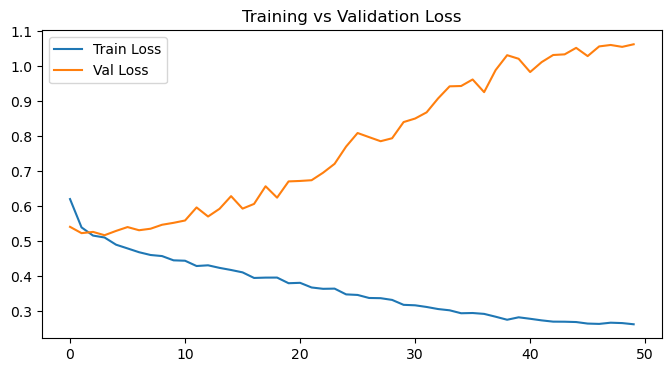

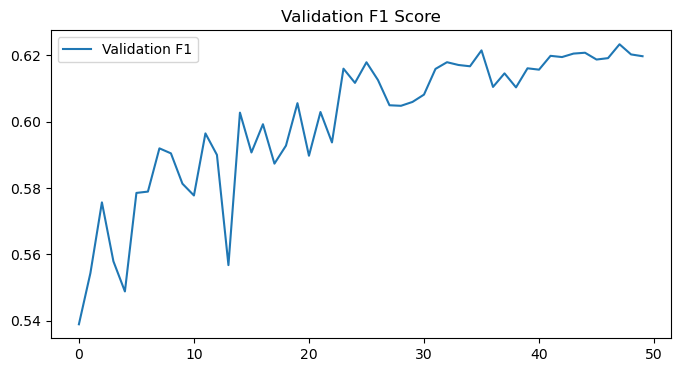

<Figure size 600x500 with 0 Axes>

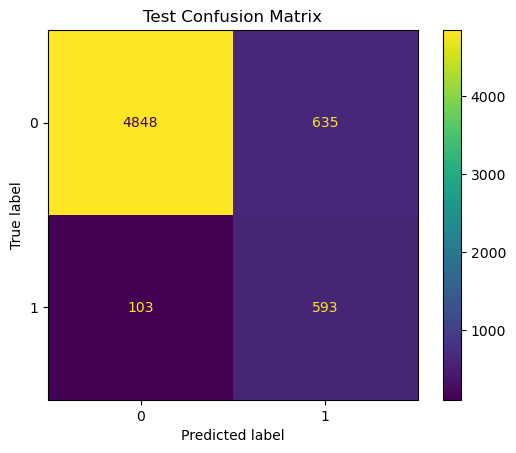

In [11]:
# Visualization

import os
os.makedirs("../results", exist_ok=True)   # ensure results folder exists at project root


# ------------------ LOSS CURVE ------------------
plt.figure(figsize=(8,4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.legend()

# SAVE BEFORE SHOW
plt.savefig("../results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------ F1 CURVE ------------------
plt.figure(figsize=(8,4))
plt.plot(history['val_f1'], label='Validation F1')
plt.title("Validation F1 Score")
plt.legend()

# SAVE F1
plt.savefig("../results/f1_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------ CONFUSION MATRIX ------------------
from sklearn.metrics import ConfusionMatrixDisplay

y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        p = torch.sigmoid(model(xb.to(device))).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend((p >= 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(values_format="d")
plt.title("Test Confusion Matrix")

# SAVE CONFUSION MATRIX
plt.savefig("../results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


## 📊 Exploratory Data Analysis (EDA)

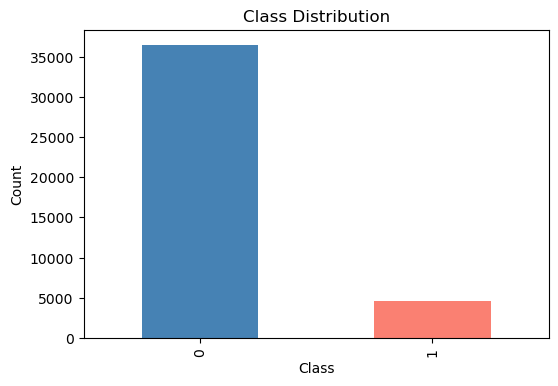

<Figure size 1200x800 with 0 Axes>

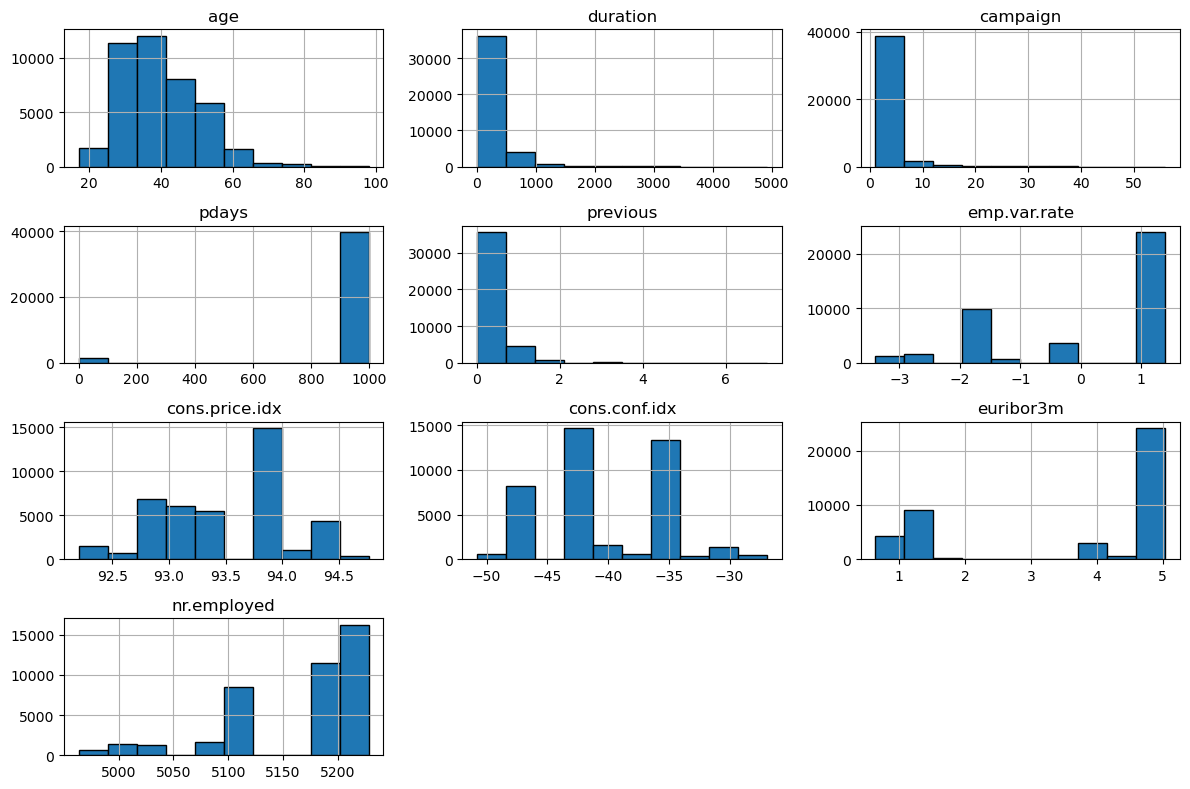

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Make sure results folder exists at the project root
os.makedirs("../results", exist_ok=True)


# ------------------ CLASS DISTRIBUTION ------------------
plt.figure(figsize=(6,4))
df['y'].value_counts().plot(kind='bar', title='Class Distribution', color=['steelblue', 'salmon'])
plt.xlabel("Class")
plt.ylabel("Count")

# Save
plt.savefig("../results/class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------ NUMERICAL HISTOGRAMS ------------------
plt.figure(figsize=(12, 8))
df[num_cols].hist(figsize=(12, 8), edgecolor='black')
plt.tight_layout()

# Save
plt.savefig("../results/numerical_histograms.png", dpi=300, bbox_inches="tight")
plt.show()


## 🔧 Preprocessing Summary

In [13]:
print('Training set:', train_df.shape)
print('Validation set:', val_df.shape)
print('Test set:', test_df.shape)

Training set: (28831, 21)
Validation set: (6178, 21)
Test set: (6179, 21)


## 🧠 Model Training Visualization

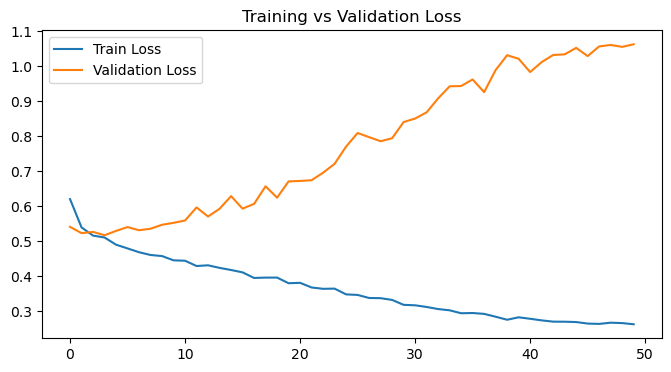

In [14]:
plt.figure(figsize=(8,4))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.legend()

# Save BEFORE show
plt.savefig("../results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## 📈 Evaluation Metrics

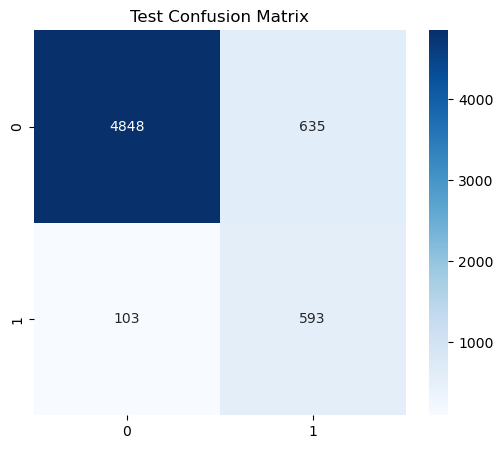

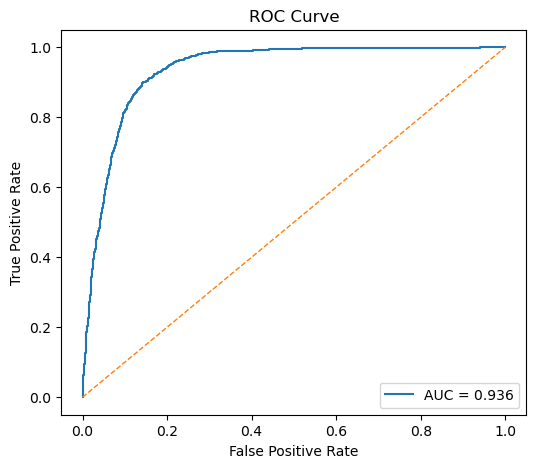

              precision    recall  f1-score   support

         0.0       0.98      0.88      0.93      5483
         1.0       0.48      0.85      0.62       696

    accuracy                           0.88      6179
   macro avg       0.73      0.87      0.77      6179
weighted avg       0.92      0.88      0.89      6179



In [15]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

# ---------------- CONFUSION MATRIX (EVALUATION) ----------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Test Confusion Matrix")

# SAVE BEFORE SHOW
plt.savefig("../results/confusion_matrix_eval.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------------- ROC CURVE ----------------
# y_probs must be collected during prediction

y_true, y_pred, y_probs = [], [], []
model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb.to(device))
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        
        y_probs.extend(probs)
        y_pred.extend((probs >= 0.5).astype(int))
        y_true.extend(yb.numpy())

fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--", linewidth=1)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

# SAVE ROC
plt.savefig("../results/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# ---------------- CLASSIFICATION REPORT ----------------
print(classification_report(y_true, y_pred))



## 🏁 <a id='conclusion'></a>Conclusion

This project demonstrates that deep learning models — specifically **Residual MLPs** — can effectively handle structured tabular data.  
Key takeaways include:

### ✅ What worked well
- Batch Normalization stabilized training  
- Dropout prevented overfitting  
- AdamW + Cosine Annealing improved convergence  
- Weighted BCE Loss handled class imbalance  
- Residual connections improved gradient flow  

### 🚀 Future Work
- Add embedding layers for categorical variables  
- Apply SHAP values for model interpretability  
- Hyperparameter tuning using Optuna  
- Compare tabular DL vs Gradient Boosting (XGBoost, CatBoost, LightGBM)

---

### 🎉 **Notebook complete.**
